# Prática 2 - Classificação de Tickets de Incidentes (Versão Offline)

**Estudo de Caso 2 — Minicurso "Inteligência Artificial aplicada à Resposta a Incidentes"**

## Sobre este notebook

Este é o plano B independente de API/internet para a Prática 2. Os **resultados**
de uma execução real e completa estão embutidos no código — não precisa de
chave de API nem de conexão. Os **tickets** continuam vindo do CSV normalmente
(é um arquivo pequeno e 100% sintético, sem necessidade de embutir).

> **Pré-requisito:** coloque `tickets_sinteticos.csv` na mesma pasta deste notebook.
> Só precisa de `pandas` e `matplotlib` — bibliotecas padrão, quase certamente
> já instaladas em qualquer ambiente Python voltado a dados.

**Os resultados são reais**, de uma execução completa (24 tickets, 4 exemplos,
20 de avaliação): **90,0% no zero-shot, 95,0% no one-shot**.


## 0. Instalando dependências

In [2]:
%pip install pandas matplotlib --quiet


Note: you may need to restart the kernel to use updated packages.


## 1. Preparação

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 11

print("Ambiente pronto.")


Ambiente pronto.


## 2. Taxonomia de referência

In [4]:
TAXONOMIA = {
    "CAT1":  "Comprometimento de Conta — acesso não autorizado a contas de usuários ou administradores",
    "CAT2":  "Malware — infecção por código malicioso que compromete dispositivos ou dados",
    "CAT3":  "Negação de Serviço (DoS/DDoS) — indisponibilidade de sistemas ou redes",
    "CAT4":  "Exfiltração/Vazamento de Dados — acesso, cópia ou divulgação não autorizada de dados sensíveis",
    "CAT5":  "Exploração de Vulnerabilidade — uso de falhas conhecidas ou desconhecidas para comprometer ativos",
    "CAT6":  "Abuso Interno — ações intencionais ou negligentes de usuários internos",
    "CAT7":  "Engenharia Social — engano de pessoas para obter acesso ou informações",
    "CAT8":  "Incidente Físico ou de Infraestrutura — violação física que impacta ativos computacionais",
    "CAT9":  "Alteração Não Autorizada — modificação não autorizada em sistemas, dados ou configurações",
    "CAT10": "Uso Indevido de Recursos — uso não autorizado de sistemas para outros fins",
    "CAT11": "Problema de Fornecedor/Terceiro — incidente originado por falha de segurança de terceiros",
    "CAT12": "Tentativa de Intrusão — tentativas hostis de invasão ainda não confirmadas como bem-sucedidas",
}
for cod, desc in TAXONOMIA.items():
    print(f"{cod}: {desc}")


CAT1: Comprometimento de Conta — acesso não autorizado a contas de usuários ou administradores
CAT2: Malware — infecção por código malicioso que compromete dispositivos ou dados
CAT3: Negação de Serviço (DoS/DDoS) — indisponibilidade de sistemas ou redes
CAT4: Exfiltração/Vazamento de Dados — acesso, cópia ou divulgação não autorizada de dados sensíveis
CAT5: Exploração de Vulnerabilidade — uso de falhas conhecidas ou desconhecidas para comprometer ativos
CAT6: Abuso Interno — ações intencionais ou negligentes de usuários internos
CAT7: Engenharia Social — engano de pessoas para obter acesso ou informações
CAT8: Incidente Físico ou de Infraestrutura — violação física que impacta ativos computacionais
CAT9: Alteração Não Autorizada — modificação não autorizada em sistemas, dados ou configurações
CAT10: Uso Indevido de Recursos — uso não autorizado de sistemas para outros fins
CAT11: Problema de Fornecedor/Terceiro — incidente originado por falha de segurança de terceiros
CAT12: Tentativ

## 3. Carregando os tickets

Os mesmos 24 tickets do notebook online, lidos normalmente do CSV. Os 4
exemplos one-shot (CAT3: T023, CAT4: T022, CAT5: T017, CAT12: T010) foram
escolhidos entre os 24.


In [5]:
df = pd.read_csv("tickets_sinteticos.csv")
print(f"{len(df)} tickets sintéticos carregados.")

exemplos_ids = ["T017", "T023", "T010", "T022"]
df_exemplos = df[df["id"].isin(exemplos_ids)].copy()
df_avaliacao = df[~df["id"].isin(exemplos_ids)].reset_index(drop=True)

print(f"Exemplos one-shot: {len(df_exemplos)}")
for _, row in df_exemplos.sort_values("categoria", key=lambda s: s.str.replace("CAT", "").astype(int)).iterrows():
    print(f"  {row['categoria']}: {row['id']}")
print(f"\nAvaliação: {len(df_avaliacao)} tickets")


24 tickets sintéticos carregados.
Exemplos one-shot: 4
  CAT3: T023
  CAT4: T022
  CAT5: T017
  CAT12: T010

Avaliação: 20 tickets


## 4. Resultados reais — os 20 tickets de avaliação

In [6]:
# zero-shot, one-shot, rótulo livre — dados reais de uma execução completa
RESULTADOS = {
    "T001": ("CAT12", "CAT5",  "Configuração de rede insegura"),
    "T002": ("CAT12", "CAT12", "Ataque de força bruta"),
    "T003": ("CAT3",  "CAT3",  "Ataque de Negação de Serviço"),
    "T004": ("CAT2",  "CAT2",  "Infecção por Malware"),
    "T005": ("CAT7",  "CAT7",  "Tentativa de Phishing"),
    "T006": ("CAT1",  "CAT1",  "Comprometimento de conta"),
    "T007": ("CAT5",  "CAT5",  "Vulnerabilidade Crítica de Execução"),
    "T008": ("CAT9",  "CAT9",  "Violação de controle interno"),
    "T009": ("CAT4",  "CAT4",  "Vazamento de dados sensíveis"),
    "T011": ("CAT10", "CAT10", "Mineração de criptomoedas"),
    "T012": ("CAT11", "CAT11", "Vazamento de dados"),
    "T013": ("CAT5",  "CAT5",  "Vulnerabilidade de aplicação web"),
    "T014": ("CAT3",  "CAT3",  "Ataque de Negação de Serviço"),
    "T015": ("CAT2",  "CAT2",  "Incidente de Ransomware"),
    "T016": ("CAT6",  "CAT6",  "Acesso indevido a dados"),
    "T018": ("CAT12", "CAT12", "Tentativa de Exploração"),
    "T019": ("CAT8",  "CAT8",  "Incidente de infraestrutura física"),
    "T020": ("CAT9",  "CAT9",  "Comprometimento de aplicação web"),
    "T021": ("CAT7",  "CAT7",  "Engenharia Social (Phishing)"),
    "T024": ("CAT2",  "CAT2",  "Comprometimento de Ativo"),
}

df_resultados = pd.DataFrame(
    [(tid, z, o, rl) for tid, (z, o, rl) in RESULTADOS.items()],
    columns=["id", "zero_shot", "one_shot", "rotulo_livre"],
)
df_resultados = df_avaliacao[["id", "categoria"]].merge(df_resultados, on="id").rename(columns={"categoria": "esperado"})

for col in ["zero_shot", "one_shot"]:
    df_resultados[f"{col}_ok"] = df_resultados[col] == df_resultados["esperado"]

df_resultados[["id", "esperado", "zero_shot", "one_shot"]]


,id,esperado,zero_shot,one_shot
0,T001,CAT5,CAT12,CAT5
1,T002,CAT12,CAT12,CAT12
2,T003,CAT3,CAT3,CAT3
3,T004,CAT2,CAT2,CAT2
4,T005,CAT7,CAT7,CAT7
5,T006,CAT1,CAT1,CAT1
6,T007,CAT5,CAT5,CAT5
7,T008,CAT9,CAT9,CAT9
8,T009,CAT4,CAT4,CAT4
9,T011,CAT10,CAT10,CAT10


In [7]:
def colorir_resultado(val):
    if val is True:
        return "background-color: #d4edda; color: #155724"
    elif val is False:
        return "background-color: #f8d7da; color: #721c24"
    return ""

(
    df_resultados[["id", "esperado", "zero_shot", "one_shot", "zero_shot_ok", "one_shot_ok"]]
    .style
    .map(colorir_resultado, subset=["zero_shot_ok", "one_shot_ok"])
    .set_caption("Resultado por ticket — verde = acerto, vermelho = erro")
)


,id,esperado,zero_shot,one_shot,zero_shot_ok,one_shot_ok
0,T001,CAT5,CAT12,CAT5,False,True
1,T002,CAT12,CAT12,CAT12,True,True
2,T003,CAT3,CAT3,CAT3,True,True
3,T004,CAT2,CAT2,CAT2,True,True
4,T005,CAT7,CAT7,CAT7,True,True
5,T006,CAT1,CAT1,CAT1,True,True
6,T007,CAT5,CAT5,CAT5,True,True
7,T008,CAT9,CAT9,CAT9,True,True
8,T009,CAT4,CAT4,CAT4,True,True
9,T011,CAT10,CAT10,CAT10,True,True


## 5. Gráfico: ganho do one-shot

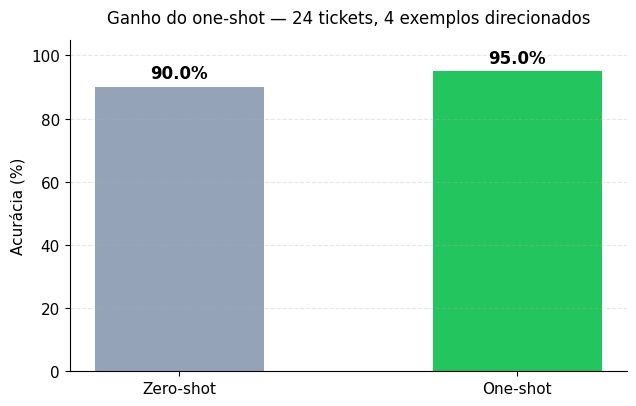

Ganho absoluto: 5.0 pontos percentuais


In [8]:
acc_zero = df_resultados["zero_shot_ok"].mean() * 100
acc_one = df_resultados["one_shot_ok"].mean() * 100

fig, ax = plt.subplots(figsize=(6.5, 4.2))
barras = ax.bar(["Zero-shot", "One-shot"], [acc_zero, acc_one], color=["#94a3b8", "#22c55e"], width=0.5)
for barra, valor in zip(barras, [acc_zero, acc_one]):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 1.5, f"{valor:.1f}%",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 105)
ax.set_ylabel("Acurácia (%)")
ax.set_title("Ganho do one-shot — 24 tickets, 4 exemplos direcionados", fontsize=12, pad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Ganho absoluto: {acc_one - acc_zero:.1f} pontos percentuais")


## 6. Matriz de confusão

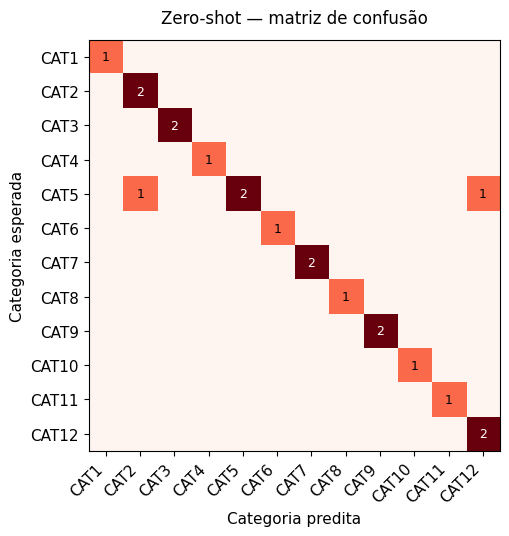

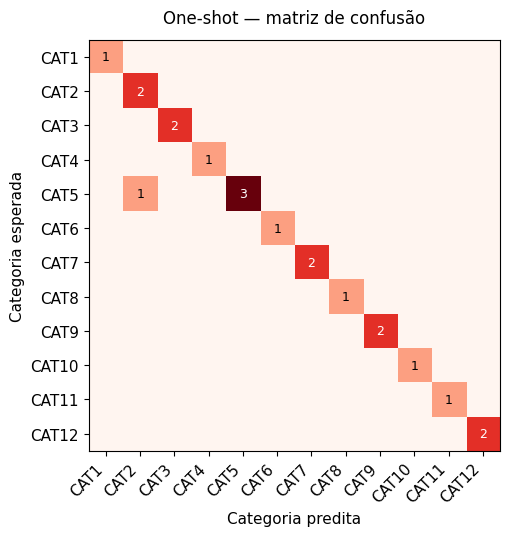

In [9]:
def plotar_matriz_confusao(df_r, coluna_predita, titulo):
    categorias = sorted(
        set(df_r["esperado"]) | set(df_r[coluna_predita].dropna()),
        key=lambda c: int(c.replace("CAT", "")),
    )
    matriz = pd.crosstab(df_r["esperado"], df_r[coluna_predita]).reindex(
        index=categorias, columns=categorias, fill_value=0
    )
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(matriz.values, cmap="Reds")
    ax.set_xticks(range(len(categorias)))
    ax.set_yticks(range(len(categorias)))
    ax.set_xticklabels(categorias, rotation=45, ha="right")
    ax.set_yticklabels(categorias)
    ax.set_xlabel("Categoria predita")
    ax.set_ylabel("Categoria esperada")
    ax.set_title(titulo, fontsize=12, pad=12)
    for i in range(len(categorias)):
        for j in range(len(categorias)):
            valor = matriz.values[i, j]
            if valor > 0:
                cor = "white" if valor > matriz.values.max() / 2 else "black"
                ax.text(j, i, str(valor), ha="center", va="center", color=cor, fontsize=9)
    plt.tight_layout()
    plt.show()

plotar_matriz_confusao(df_resultados, "zero_shot", "Zero-shot — matriz de confusão")
plotar_matriz_confusao(df_resultados, "one_shot", "One-shot — matriz de confusão")


## 7. Discussão

### O que os dados reais mostram

- **90,0% → 95,0%** de acurácia, com apenas 4 exemplos one-shot escolhidos por
  diagnóstico — não sorteados, não criados à parte, apenas **selecionados**
  entre os 24 tickets originais.
- **T001 foi corrigido.** Ele e o exemplo T017 compartilham o mesmo mecanismo
  técnico (amplificação de tráfego via serviço de rede mal configurado); T017
  foi escolhido como exemplo justamente por isso.
- **T024 permanece errado** — e não é falha do experimento. É o mesmo ticket
  que já resistiu a toda técnica testada neste minicurso inteiro. O relato é
  vago demais ("atividade incomum", sem detalhe técnico) para qualquer
  estratégia de prompt recuperar informação que nunca esteve no texto original.

### Conexão com o experimento na base real

A mesma confusão-chave (CAT5↔CAT12, e sua variante pelo mesmo mecanismo de
amplificação) foi o achado dominante no experimento com os 182 tickets reais.
Ver esse padrão se repetir — e ser corrigido pela mesma lógica de exemplo
direcionado — numa base sintética pequena é uma validação cruzada direta entre
os dois experimentos.
